# Drowsiness Detection Pipeline

This notebook starts from already extracted CSV features.

Models used:

1. Multilayer Perceptron Neural Network

Dataset split:

- Training set
- Validation set
- Test set


In [1]:
import os
import pandas as pd
import numpy as np
import joblib

import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.preprocessing import LabelEncoder, StandardScaler
from sklearn.model_selection import train_test_split

from sklearn.neural_network import MLPClassifier
from sklearn.linear_model import LogisticRegression

from sklearn.metrics import (
    accuracy_score,
    classification_report,
    confusion_matrix
)

sns.set(style="whitegrid")

In [5]:
features_progress_path = "features_progress.csv"
features_normalized_path = "features_normalized.csv"
window_features_path = "window_features.csv"

output_dir = "mlp-outputs"
os.makedirs(output_dir, exist_ok=True)

print("features_progress_path exists:", os.path.exists(features_progress_path))
print("features_normalized_path exists:", os.path.exists(features_normalized_path))
print("window_features_path exists:", os.path.exists(window_features_path))
print("Output directory:", output_dir)

features_progress_path exists: True
features_normalized_path exists: True
window_features_path exists: True
Output directory: mlp-outputs


In [6]:
features_df = pd.read_csv(features_progress_path)

print("Loaded frame-level rows:", len(features_df))
display(features_df.head())

Loaded frame-level rows: 235706


,subject,label,frame,EAR,MAR,pitch,yaw,video_path
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...


In [7]:
print("Columns in features_df:")
print(features_df.columns.tolist())

required_cols = [
    "subject", "label", "frame", "EAR", "MAR", "pitch", "yaw", "video_path"
]

missing_cols = [col for col in required_cols if col not in features_df.columns]

if len(missing_cols) > 0:
    print("Missing columns:", missing_cols)
else:
    print("All required columns are present.")

Columns in features_df:
['subject', 'label', 'frame', 'EAR', 'MAR', 'pitch', 'yaw', 'video_path']
All required columns are present.


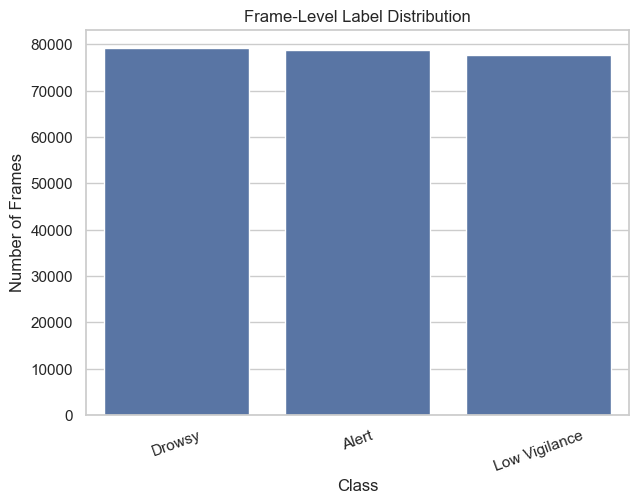

label
Drowsy           79170
Alert            78799
Low Vigilance    77737
Name: count, dtype: int64


In [8]:
plt.figure(figsize=(7, 5))
sns.countplot(data=features_df, x="label", order=features_df["label"].value_counts().index)
plt.title("Frame-Level Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Frames")
plt.xticks(rotation=20)
plt.show()

print(features_df["label"].value_counts())

In [9]:
numeric_cols = ["EAR", "MAR", "pitch", "yaw"]

baseline = (
    features_df[features_df["label"] == "Alert"]
    .groupby("subject")[numeric_cols]
    .mean()
)

def normalize(row):
    subject = row["subject"]

    if subject in baseline.index:
        row["EAR_dev"] = row["EAR"] - baseline.loc[subject, "EAR"]
        row["MAR_dev"] = row["MAR"] - baseline.loc[subject, "MAR"]
    else:
        row["EAR_dev"] = row["EAR"]
        row["MAR_dev"] = row["MAR"]

    return row

features_df = features_df.apply(normalize, axis=1)

features_df.to_csv(features_normalized_path, index=False)

print("Saved normalized features:", features_normalized_path)
display(features_df.head())

Saved normalized features: features_normalized.csv


,subject,label,frame,EAR,MAR,pitch,yaw,video_path,EAR_dev,MAR_dev
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...,0.011799,0.084260
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.060053,-0.005614
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.043445,0.011661
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.052643,0.025179
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.063962,-0.003149


In [10]:
baseline_path = os.path.join(output_dir, "baseline_by_subject.csv")

baseline.to_csv(baseline_path)

print("Baseline saved at:", baseline_path)
display(baseline.head())

Baseline saved at: mlp-outputs\baseline_by_subject.csv


,EAR,MAR,pitch,yaw
subject,,,,
1,0.303734,0.010927,230.098915,369.902234
2,0.301671,0.014962,205.900822,324.892506
3,0.283038,0.010225,203.785617,368.570744
4,0.296292,0.013034,97.361923,160.952923
5,0.327134,0.012007,194.941465,308.112217


In [11]:
features_df = pd.read_csv(features_normalized_path)

print("Normalized rows:", len(features_df))
display(features_df.head())

Normalized rows: 235706


,subject,label,frame,EAR,MAR,pitch,yaw,video_path,EAR_dev,MAR_dev
0,20,Low Vigilance,30,0.265168,0.093651,476.009454,748.818403,/kaggle/input/datasets/rishab260/uta-reallife-...,0.011799,0.084260
1,20,Low Vigilance,40,0.193316,0.003777,458.795161,741.967654,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.060053,-0.005614
2,20,Low Vigilance,50,0.209924,0.021052,417.269697,681.898819,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.043445,0.011661
3,20,Low Vigilance,60,0.200726,0.034570,373.262642,636.804523,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.052643,0.025179
4,20,Low Vigilance,70,0.189407,0.006242,360.013889,629.407658,/kaggle/input/datasets/rishab260/uta-reallife-...,-0.063962,-0.003149


In [12]:
window_size = 15
windows = []

for subject in features_df["subject"].unique():
    sub_df = features_df[features_df["subject"] == subject].copy()
    sub_df = sub_df.sort_values(["video_path", "frame"])

    for video_path in sub_df["video_path"].unique():
        vid_df = sub_df[sub_df["video_path"] == video_path]

        for i in range(len(vid_df) - window_size):
            chunk = vid_df.iloc[i:i + window_size]

            windows.append({
                "subject": subject,
                "video_path": video_path,
                "label": chunk["label"].iloc[0],

                "EAR_mean": chunk["EAR"].mean(),
                "EAR_std": chunk["EAR"].std(),
                "EAR_min": chunk["EAR"].min(),

                "MAR_mean": chunk["MAR"].mean(),
                "MAR_max": chunk["MAR"].max(),

                "pitch_mean": chunk["pitch"].mean(),
                "yaw_mean": chunk["yaw"].mean(),

                "EAR_dev_mean": chunk["EAR_dev"].mean(),
                "MAR_dev_mean": chunk["MAR_dev"].mean()
            })

window_df = pd.DataFrame(windows)

window_df.to_csv(window_features_path, index=False)

print("Window rows:", len(window_df))
print("Saved window features:", window_features_path)

display(window_df.head())

Window rows: 233591
Saved window features: window_features.csv


,subject,video_path,label,EAR_mean,EAR_std,EAR_min,MAR_mean,MAR_max,pitch_mean,yaw_mean,EAR_dev_mean,MAR_dev_mean
0,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.237036,0.037249,0.137103,0.036132,0.199047,370.103525,635.342636,-0.016333,0.026740
1,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.247254,0.045480,0.137103,0.035163,0.199047,332.952045,581.059837,-0.006115,0.025772
2,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.252945,0.050826,0.137103,0.029647,0.199047,327.099773,572.753631,-0.000425,0.020256
3,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.257431,0.055144,0.137103,0.030483,0.199047,314.021163,556.392134,0.004062,0.021092
4,20,/kaggle/input/datasets/rishab260/uta-reallife-...,Alert,0.256823,0.055100,0.137103,0.018152,0.042090,303.104617,530.404469,0.003454,0.008761


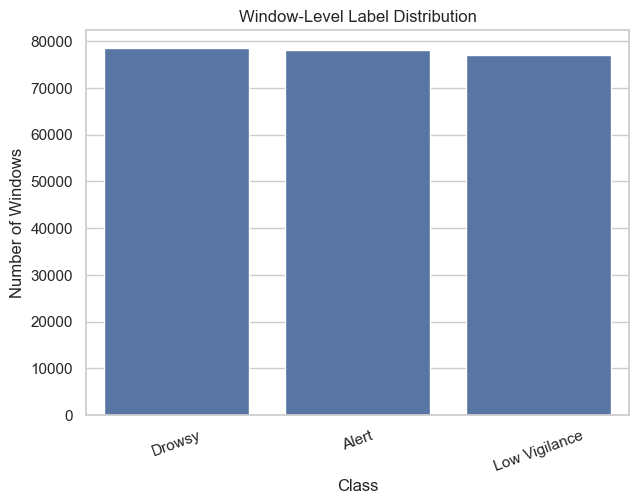

label
Drowsy           78465
Alert            78094
Low Vigilance    77032
Name: count, dtype: int64


In [13]:
plt.figure(figsize=(7, 5))
sns.countplot(data=window_df, x="label", order=window_df["label"].value_counts().index)
plt.title("Window-Level Label Distribution")
plt.xlabel("Class")
plt.ylabel("Number of Windows")
plt.xticks(rotation=20)
plt.show()

print(window_df["label"].value_counts())

In [14]:
le = LabelEncoder()

window_df["y"] = le.fit_transform(window_df["label"])

drop_cols = ["label", "y", "subject", "video_path"]

X = window_df.drop(drop_cols, axis=1)
y = window_df["y"]

# Fill possible missing values
X = X.fillna(0)

print("Feature columns:")
print(X.columns.tolist())

print("X shape:", X.shape)
print("y shape:", y.shape)

print("Classes:")
for idx, cls in enumerate(le.classes_):
    print(idx, "=", cls)

Feature columns:
['EAR_mean', 'EAR_std', 'EAR_min', 'MAR_mean', 'MAR_max', 'pitch_mean', 'yaw_mean', 'EAR_dev_mean', 'MAR_dev_mean']
X shape: (233591, 9)
y shape: (233591,)
Classes:
0 = Alert
1 = Drowsy
2 = Low Vigilance


In [15]:
# First split: 70% train, 30% temporary
X_train, X_temp, y_train, y_temp = train_test_split(
    X,
    y,
    test_size=0.30,
    random_state=42,
    stratify=y
)

# Second split: split temporary into 15% validation and 15% test
X_val, X_test, y_val, y_test = train_test_split(
    X_temp,
    y_temp,
    test_size=0.50,
    random_state=42,
    stratify=y_temp
)

print("Training set:", X_train.shape, y_train.shape)
print("Validation set:", X_val.shape, y_val.shape)
print("Test set:", X_test.shape, y_test.shape)

Training set: (163513, 9) (163513,)
Validation set: (35039, 9) (35039,)
Test set: (35039, 9) (35039,)


In [16]:
scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_val_scaled = scaler.transform(X_val)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed.")

Scaling completed.


In [17]:
def evaluate_model(model, X_data, y_true, dataset_name, model_name):
    pred = model.predict(X_data)

    acc = accuracy_score(y_true, pred)

    print("=" * 60)
    print(f"{model_name} Results on {dataset_name}")
    print("=" * 60)
    print(f"Accuracy: {acc:.4f}")
    print(f"Accuracy Percentage: {acc * 100:.2f}%")
    print()
    print("Classification Report:")
    print(classification_report(y_true, pred, target_names=le.classes_))

    cm = confusion_matrix(y_true, pred)

    plt.figure(figsize=(7, 5))
    sns.heatmap(
        cm,
        annot=True,
        fmt="d",
        cmap="Blues",
        xticklabels=le.classes_,
        yticklabels=le.classes_
    )
    plt.title(f"{model_name} Confusion Matrix - {dataset_name}")
    plt.xlabel("Predicted Label")
    plt.ylabel("True Label")
    plt.show()

    return acc, pred

In [18]:
mlp_model = MLPClassifier(
    hidden_layer_sizes=(128, 64, 32),
    activation="relu",
    solver="adam",
    alpha=0.0001,
    batch_size=64,
    learning_rate="adaptive",
    learning_rate_init=0.001,
    max_iter=300,
    random_state=42,
    early_stopping=True,
    validation_fraction=0.15,
    n_iter_no_change=20,
    verbose=True
)

mlp_model.fit(X_train_scaled, y_train)

print("MLP training completed.")

Iteration 1, loss = 0.69437992
Validation score: 0.777592
Iteration 2, loss = 0.45546349
Validation score: 0.835895
Iteration 3, loss = 0.35235313
Validation score: 0.876707
Iteration 4, loss = 0.28937522
Validation score: 0.884209
Iteration 5, loss = 0.25183201
Validation score: 0.888246
Iteration 6, loss = 0.22539870
Validation score: 0.923676
Iteration 7, loss = 0.20429940
Validation score: 0.922738
Iteration 8, loss = 0.18921249
Validation score: 0.930729
Iteration 9, loss = 0.18050353
Validation score: 0.936111
Iteration 10, loss = 0.16979930
Validation score: 0.934929
Iteration 11, loss = 0.15965220
Validation score: 0.933583
Iteration 12, loss = 0.15481734
Validation score: 0.940800
Iteration 13, loss = 0.14824742
Validation score: 0.939821
Iteration 14, loss = 0.14185971
Validation score: 0.944266
Iteration 15, loss = 0.13977257
Validation score: 0.948628
Iteration 16, loss = 0.13478659
Validation score: 0.946019
Iteration 17, loss = 0.12950851
Validation score: 0.951971
Iterat

MLP Neural Network Results on Validation Set
Accuracy: 0.9794
Accuracy Percentage: 97.94%

Classification Report:
               precision    recall  f1-score   support

        Alert       0.98      0.99      0.98     11714
       Drowsy       0.98      0.98      0.98     11770
Low Vigilance       0.98      0.97      0.98     11555

     accuracy                           0.98     35039
    macro avg       0.98      0.98      0.98     35039
 weighted avg       0.98      0.98      0.98     35039



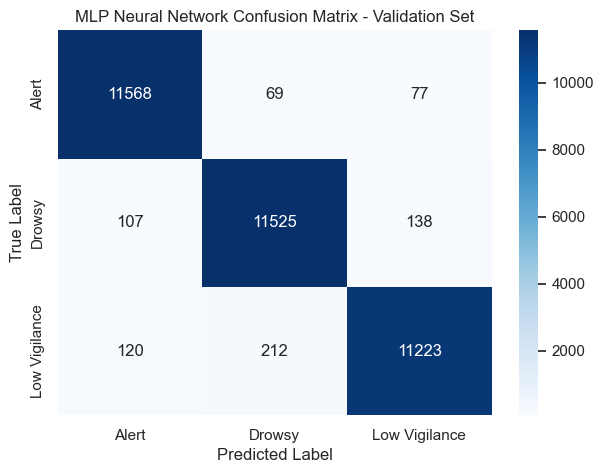

MLP Neural Network Results on Test Set
Accuracy: 0.9802
Accuracy Percentage: 98.02%

Classification Report:
               precision    recall  f1-score   support

        Alert       0.98      0.99      0.98     11714
       Drowsy       0.98      0.98      0.98     11770
Low Vigilance       0.98      0.97      0.98     11555

     accuracy                           0.98     35039
    macro avg       0.98      0.98      0.98     35039
 weighted avg       0.98      0.98      0.98     35039



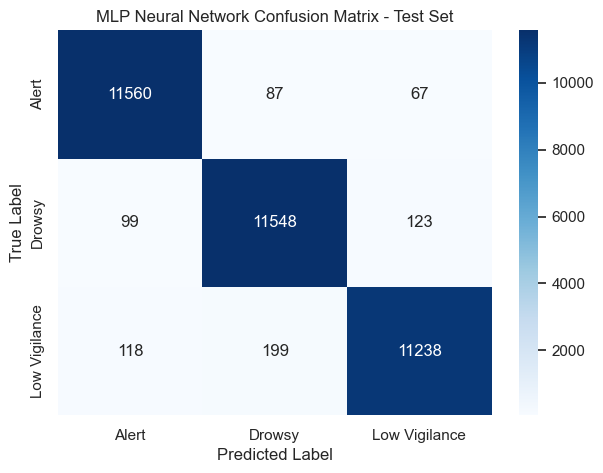

In [19]:
mlp_val_acc, mlp_val_pred = evaluate_model(
    mlp_model,
    X_val_scaled,
    y_val,
    dataset_name="Validation Set",
    model_name="MLP Neural Network"
)

mlp_test_acc, mlp_test_pred = evaluate_model(
    mlp_model,
    X_test_scaled,
    y_test,
    dataset_name="Test Set",
    model_name="MLP Neural Network"
)

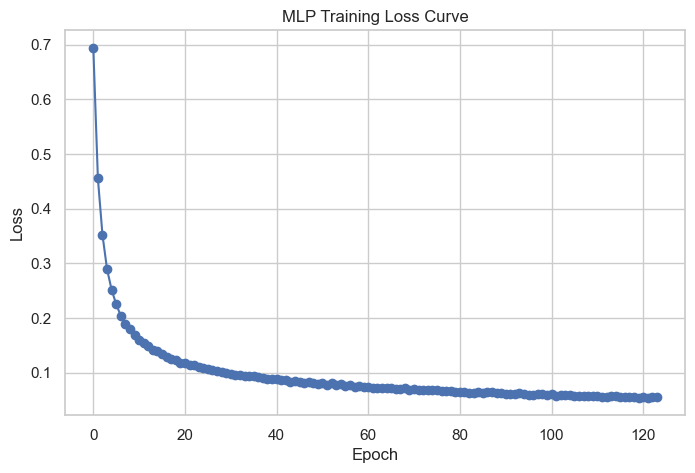

In [20]:
plt.figure(figsize=(8, 5))
plt.plot(mlp_model.loss_curve_, marker="o")
plt.title("MLP Training Loss Curve")
plt.xlabel("Epoch")
plt.ylabel("Loss")
plt.grid(True)
plt.show()

In [ ]:
# Logistic Regression model removed - MLP is the recommended model

Multinomial Logistic Regression training completed.


Multinomial Logistic Regression Results on Validation Set
Accuracy: 0.4681
Accuracy Percentage: 46.81%

Classification Report:
               precision    recall  f1-score   support

        Alert       0.49      0.67      0.56     11714
       Drowsy       0.51      0.54      0.52     11770
Low Vigilance       0.34      0.19      0.25     11555

     accuracy                           0.47     35039
    macro avg       0.45      0.47      0.45     35039
 weighted avg       0.45      0.47      0.45     35039



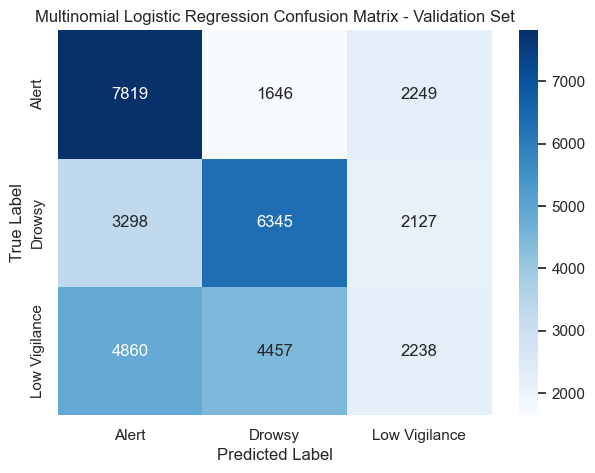

Multinomial Logistic Regression Results on Test Set
Accuracy: 0.4687
Accuracy Percentage: 46.87%

Classification Report:
               precision    recall  f1-score   support

        Alert       0.49      0.66      0.56     11714
       Drowsy       0.51      0.55      0.53     11770
Low Vigilance       0.34      0.20      0.25     11555

     accuracy                           0.47     35039
    macro avg       0.45      0.47      0.45     35039
 weighted avg       0.45      0.47      0.45     35039



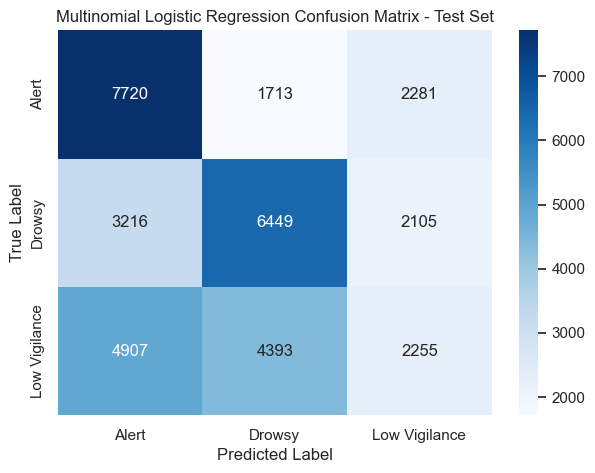

In [ ]:
# Logistic Regression evaluation removed - MLP is the recommended model
print("Logistic Regression code removed. Using MLP Neural Network only.")

,Model,Dataset,Accuracy
0,MLP Neural Network,Validation,0.979366
1,MLP Neural Network,Test,0.980222
2,Multinomial Logistic Regression,Validation,0.468107
3,Multinomial Logistic Regression,Test,0.468735


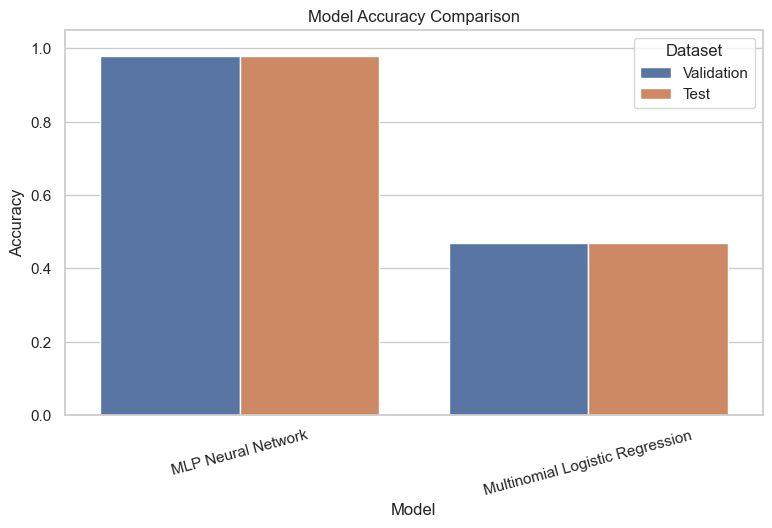

In [ ]:
accuracy_results = pd.DataFrame({
    "Model": [
        "MLP Neural Network",
        "MLP Neural Network"
    ],
    "Dataset": [
        "Validation",
        "Test"
    ],
    "Accuracy": [
        mlp_val_acc,
        mlp_test_acc
    ]
})

display(accuracy_results)

plt.figure(figsize=(8, 5))
sns.barplot(
    data=accuracy_results,
    x="Model",
    y="Accuracy",
    hue="Dataset"
)
plt.title("MLP Neural Network Accuracy")
plt.ylim(0.95, 1.0)
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.xticks(rotation=15)
plt.legend(title="Dataset")
plt.show()

In [24]:
joblib.dump(mlp_model, os.path.join(output_dir, "mlp_neural_network_model.pkl"))
joblib.dump(log_reg_model, os.path.join(output_dir, "multinomial_logistic_regression_model.pkl"))

joblib.dump(scaler, os.path.join(output_dir, "standard_scaler.pkl"))
joblib.dump(le, os.path.join(output_dir, "label_encoder.pkl"))
joblib.dump(list(X.columns), os.path.join(output_dir, "feature_columns.pkl"))

print("Saved files:")
print(os.path.join(output_dir, "mlp_neural_network_model.pkl"))
print(os.path.join(output_dir, "multinomial_logistic_regression_model.pkl"))
print(os.path.join(output_dir, "standard_scaler.pkl"))
print(os.path.join(output_dir, "label_encoder.pkl"))
print(os.path.join(output_dir, "feature_columns.pkl"))

Saved files:
mlp-outputs\mlp_neural_network_model.pkl
mlp-outputs\multinomial_logistic_regression_model.pkl
mlp-outputs\standard_scaler.pkl
mlp-outputs\label_encoder.pkl
mlp-outputs\feature_columns.pkl


In [ ]:
mlp_report = classification_report(
    y_test,
    mlp_test_pred,
    target_names=le.classes_
)

with open(os.path.join(output_dir, "mlp_classification_report.txt"), "w") as f:
    f.write("MLP Neural Network Test Report\n")
    f.write("=" * 50)
    f.write("\n")
    f.write(mlp_report)
    f.write("\n")
    f.write(f"Test Accuracy: {mlp_test_acc:.4f}")
    f.write("\n")
    f.write(f"Test Accuracy Percentage: {mlp_test_acc * 100:.2f}%")

print("MLP Classification Report saved.")

Reports saved.


In [ ]:
print("=" * 60)
print("Final Model Accuracy Summary")
print("=" * 60)

print(f"MLP Validation Accuracy: {mlp_val_acc:.4f}")
print(f"MLP Test Accuracy:       {mlp_test_acc:.4f}")

print("=" * 60)
print("Recommended Model: MLP Neural Network")
print("=" * 60)

Final Model Accuracy Summary
MLP Validation Accuracy: 0.9794
MLP Test Accuracy:       0.9802

LogReg Validation Accuracy: 0.4681
LogReg Test Accuracy:       0.4687
Best model on test data: MLP Neural Network


c:\Users\PMLS\AppData\Local\Programs\Python\Python312\Lib\site-packages\google\protobuf\symbol_database.py:55: UserWarning: SymbolDatabase.GetPrototype() is deprecated. Please use message_factory.GetMessageClass() instead. SymbolDatabase.GetPrototype() will be removed soon.
  warnings.warn('SymbolDatabase.GetPrototype() is deprecated. Please '


Video path: test1.mp4
Sampled frames: 127
Detected-face frames: 127
Extracted rows: 127
Window prediction counts:
- Drowsy: 113
Final video prediction: Drowsy


,class,avg_probability
1,Drowsy,1.000000e+00
0,Alert,1.886199e-28
2,Low Vigilance,1.478123e-79


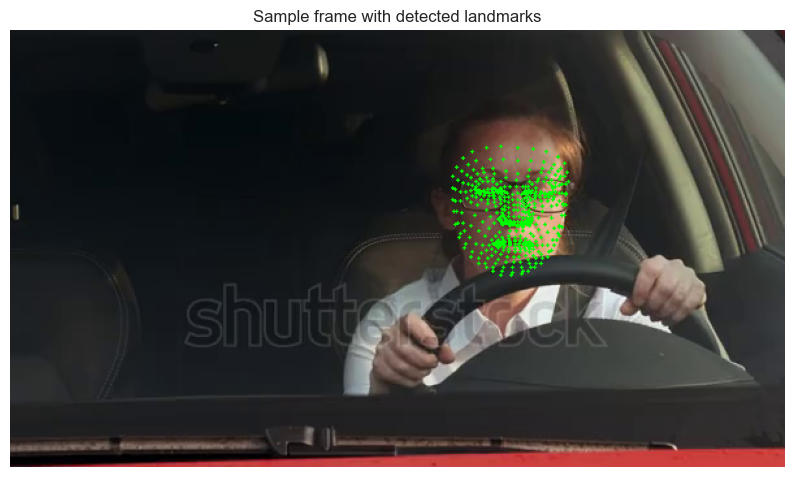

,EAR_mean,EAR_std,EAR_min,MAR_mean,MAR_max,pitch_mean,yaw_mean,EAR_dev_mean,MAR_dev_mean
0,0.101146,0.029956,0.062892,0.357927,0.790569,45.220114,82.268339,0.101146,0.357927
1,0.103018,0.031284,0.062892,0.409745,0.790569,45.722295,82.071311,0.103018,0.409745
2,0.102797,0.031336,0.062892,0.451899,0.790569,46.136606,81.941238,0.102797,0.451899
3,0.105033,0.031239,0.062892,0.498120,0.790569,46.554727,81.940837,0.105033,0.498120
4,0.106628,0.029496,0.065209,0.532139,0.790569,46.813195,82.009072,0.106628,0.532139


In [32]:
import cv2
import numpy as np
from collections import Counter

try:
    import mediapipe as mp
except ImportError:
    raise ImportError("mediapipe not installed. Run: pip install mediapipe")

# Video detection test using the trained MLP pipeline
VIDEO_CANDIDATES = [r"test1.mp4", r"test data/1.mp4"]
VIDEO_PATH = next((path for path in VIDEO_CANDIDATES if os.path.exists(path)), None)
SAMPLE_EVERY_N_FRAMES = 5
MAX_SAMPLED_FRAMES = 6000
WINDOW_SIZE = 15

if VIDEO_PATH is None:
    raise FileNotFoundError(f"No test video found. Checked: {VIDEO_CANDIDATES}")

LEFT_EYE = [33, 160, 158, 133, 153, 144]
RIGHT_EYE = [362, 385, 387, 263, 373, 380]
MOUTH_TOP, MOUTH_BOTTOM, MOUTH_LEFT, MOUTH_RIGHT = 13, 14, 78, 308
NOSE, CHIN, LEFT_FACE, RIGHT_FACE = 1, 152, 234, 454

mp_face_mesh = mp.solutions.face_mesh

def compute_EAR(landmarks_xy, eye):
    p1, p2, p3, p4, p5, p6 = [np.array(landmarks_xy[i][:2]) for i in eye]
    vertical1 = np.linalg.norm(p2 - p6)
    vertical2 = np.linalg.norm(p3 - p5)
    horizontal = np.linalg.norm(p1 - p4)
    return (vertical1 + vertical2) / (2.0 * horizontal + 1e-6)

def compute_MAR(landmarks_xy):
    top = np.array(landmarks_xy[MOUTH_TOP][:2])
    bottom = np.array(landmarks_xy[MOUTH_BOTTOM][:2])
    left = np.array(landmarks_xy[MOUTH_LEFT][:2])
    right = np.array(landmarks_xy[MOUTH_RIGHT][:2])
    vertical = np.linalg.norm(top - bottom)
    horizontal = np.linalg.norm(left - right)
    return vertical / (horizontal + 1e-6)

def compute_head_pose_approx(landmarks_xy):
    nose = np.array(landmarks_xy[NOSE][:2])
    chin = np.array(landmarks_xy[CHIN][:2])
    left = np.array(landmarks_xy[LEFT_FACE][:2])
    right = np.array(landmarks_xy[RIGHT_FACE][:2])
    pitch = np.linalg.norm(nose - chin)
    yaw = np.linalg.norm(left - right)
    return pitch, yaw

model_path = os.path.join(output_dir, "mlp_neural_network_model.pkl")
scaler_path = os.path.join(output_dir, "standard_scaler.pkl")
le_path = os.path.join(output_dir, "label_encoder.pkl")
feature_columns_path = os.path.join(output_dir, "feature_columns.pkl")

if "mlp_model" in globals():
    video_model = mlp_model
else:
    video_model = joblib.load(model_path)

if "scaler" in globals():
    video_scaler = scaler
else:
    video_scaler = joblib.load(scaler_path)

if "le" in globals():
    video_le = le
else:
    video_le = joblib.load(le_path)

video_feature_columns = list(X.columns) if "X" in globals() else joblib.load(feature_columns_path)

rows = []
frame_vis_bgr = None
sampled_count = 0
face_ok_count = 0

cap = cv2.VideoCapture(VIDEO_PATH)
if not cap.isOpened():
    raise RuntimeError(f"Could not open video: {VIDEO_PATH}")

with mp_face_mesh.FaceMesh(
    static_image_mode=False,
    max_num_faces=1,
    refine_landmarks=True,
    min_detection_confidence=0.5,
    min_tracking_confidence=0.5
) as face_mesh:
    frame_id = 0
    while True:
        ret, frame = cap.read()
        if not ret:
            break

        frame_id += 1
        if frame_id % SAMPLE_EVERY_N_FRAMES != 0:
            continue

        sampled_count += 1
        if sampled_count > MAX_SAMPLED_FRAMES:
            break

        rgb = cv2.cvtColor(frame, cv2.COLOR_BGR2RGB)
        result = face_mesh.process(rgb)
        if not result.multi_face_landmarks:
            continue

        h, w, _ = frame.shape
        face_landmarks = result.multi_face_landmarks[0]
        landmarks_xy = [(int(lm.x * w), int(lm.y * h), lm.z) for lm in face_landmarks.landmark]

        try:
            left_ear = compute_EAR(landmarks_xy, LEFT_EYE)
            right_ear = compute_EAR(landmarks_xy, RIGHT_EYE)
            ear = (left_ear + right_ear) / 2.0
            mar = compute_MAR(landmarks_xy)
            pitch, yaw = compute_head_pose_approx(landmarks_xy)
        except Exception:
            continue

        face_ok_count += 1
        rows.append({
            "frame": frame_id,
            "EAR": ear,
            "MAR": mar,
            "pitch": pitch,
            "yaw": yaw,
            "video_path": VIDEO_PATH
        })

        if frame_vis_bgr is None:
            frame_vis_bgr = frame.copy()
            for (x, y, _) in landmarks_xy:
                cv2.circle(frame_vis_bgr, (x, y), 1, (0, 255, 0), -1)

cap.release()

features_df = pd.DataFrame(rows)
print(f"Video path: {VIDEO_PATH}")
print(f"Sampled frames: {sampled_count}")
print(f"Detected-face frames: {face_ok_count}")
print(f"Extracted rows: {len(features_df)}")

if len(features_df) == 0:
    raise RuntimeError("No features extracted. Try reducing SAMPLE_EVERY_N_FRAMES or using another video.")

features_df["EAR_dev"] = features_df["EAR"]
features_df["MAR_dev"] = features_df["MAR"]

windows = []
for i in range(len(features_df) - WINDOW_SIZE + 1):
    chunk = features_df.iloc[i:i + WINDOW_SIZE]
    windows.append({
        "EAR_mean": chunk["EAR"].mean(),
        "EAR_std": chunk["EAR"].std(),
        "EAR_min": chunk["EAR"].min(),
        "MAR_mean": chunk["MAR"].mean(),
        "MAR_max": chunk["MAR"].max(),
        "pitch_mean": chunk["pitch"].mean(),
        "yaw_mean": chunk["yaw"].mean(),
        "EAR_dev_mean": chunk["EAR_dev"].mean(),
        "MAR_dev_mean": chunk["MAR_dev"].mean()
    })

window_df = pd.DataFrame(windows)
if len(window_df) == 0:
    raise RuntimeError(f"Not enough rows for window prediction. Need at least {WINDOW_SIZE} sampled rows.")

X_live = window_df[video_feature_columns].fillna(0)
X_live_scaled = video_scaler.transform(X_live)

pred_encoded = video_model.predict(X_live_scaled)
pred_labels = video_le.inverse_transform(pred_encoded)
counts = Counter(pred_labels)
final_prediction = counts.most_common(1)[0][0]

print("Window prediction counts:")
for cls, cnt in counts.items():
    print(f"- {cls}: {cnt}")

print("Final video prediction:", final_prediction)

if hasattr(video_model, "predict_proba"):
    probs = video_model.predict_proba(X_live_scaled).mean(axis=0)
    prob_df = pd.DataFrame({
        "class": video_le.classes_,
        "avg_probability": probs
    }).sort_values("avg_probability", ascending=False)
    display(prob_df)

if frame_vis_bgr is not None:
    plt.figure(figsize=(10, 6))
    plt.imshow(cv2.cvtColor(frame_vis_bgr, cv2.COLOR_BGR2RGB))
    plt.title("Sample frame with detected landmarks")
    plt.axis("off")
    plt.show()

display(window_df.head())